# Compare model grids to wind regions

In [1]:
!cd /g/data/w42/dr6273/work/wind_drought/ 

In [89]:
import xarray as xr
import numpy as np
import zarr
import geopandas

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'

### Load data

#### Models (single time slice)

CAFE

In [3]:
cafe_fp = "/g/data/xv83/dcfp/CAFE-f6/"

In [4]:
store = zarr.storage.ZipStore(
    cafe_fp + "c5-d60-pX-f6-20201101/atmos_hybrid_daily.zarr.zip",
    mode='r'
)

In [11]:
def preprocess_sel_Aus(ds):
    return ds.sel(lat=slice(-45, -10), lon=slice(110, 155))

In [64]:
cafe_u_ref = xr.open_mfdataset(
    [store], engine="zarr", preprocess=preprocess_sel_Aus,# use_cftime=True#, chunks=chunks
)

/jobfs/163788329.gadi-pbs/ipykernel_1026248/2271720480.py:1: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  cafe_u_ref = xr.open_mfdataset(
/jobfs/163788329.gadi-pbs/ipykernel_1026248/2271720480.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's def

In [65]:
# cafe_u_ref.data_vars

In [66]:
cafe_u_ref = cafe_u_ref["u_ref"].isel(time=0, ensemble=0).compute()

DCPP

In [67]:
ec_earth_fp = "/g/data/oi10/replicas/CMIP6/DCPP/EC-Earth-Consortium/EC-Earth3/dcppA-hindcast/"

In [68]:
ec_earth_sfcWind = xr.open_mfdataset(
    ec_earth_fp + "s2019-r1i4p1f1/day/sfcWind/gr/v20220322/sfcWind_day_EC-Earth3_dcppA-hindcast_s2019-r1i4p1f1_gr_20191101-20201031.nc",
    preprocess=preprocess_sel_Aus
)

In [69]:
ec_earth_sfcWind = ec_earth_sfcWind["sfcWind"].isel(time=0)

#### Wind regions

In [96]:
wind_regions = geopandas.read_file(
    "/g/data/ng72/dr6273/work/projects/wind_drought/data/grids.shp"
)

In [97]:
# Need to convert Cartopy CRS to be compatible with GeoPandas
# https://geopandas.org/en/stable/gallery/cartopy_convert.html
# Define the CartoPy CRS object.
crs = ccrs.PlateCarree()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
wind_regions = wind_regions.to_crs(crs_proj4)

In [98]:
wind_regions

,grid,geometry
0,NEM_2030,"MULTIPOLYGON Z (((146.125 -41.097 0, 146.316 -..."
1,SE_2030,"MULTIPOLYGON Z (((143.394 -37.775 0, 143.628 -..."
2,NWIS,"POLYGON Z ((116.683 -23.334 0, 116.679 -23.308..."
3,SWIS,"POLYGON Z ((115.774 -34.513 0, 115.772 -34.512..."


#### Plot cell boundaries

Text(0.5, 1.0, 'EC-Earth')

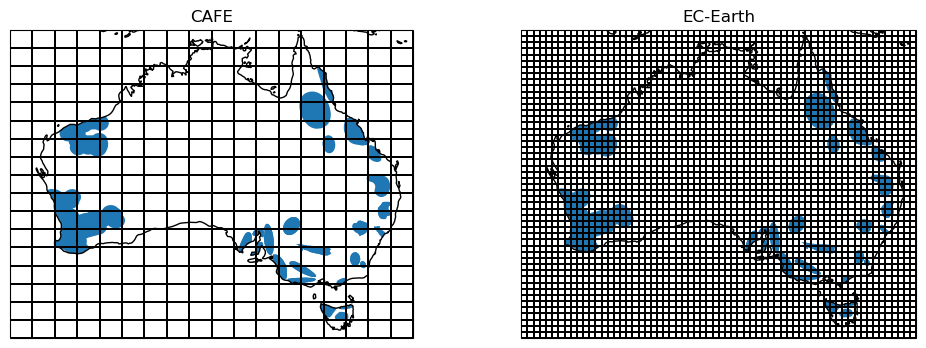

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), subplot_kw={"projection": ccrs.PlateCarree()})

ax[0].coastlines()
ax[1].coastlines()

wind_regions.plot(ax=ax[0])
p = cafe_u_ref.plot(
    ax=ax[0],
    x='lon', y='lat',
    edgecolors='k',
    linewidth=0.005,
    add_colorbar=False
)
p.set_facecolor('none')
ax[0].set_title("CAFE")


wind_regions.plot(ax=ax[1])
p = ec_earth_sfcWind.plot(
    ax=ax[1],
    x='lon', y='lat',
    edgecolors='k',
    linewidth=0.005,
    add_colorbar=False
)
p.set_facecolor('none')
ax[1].set_title("EC-Earth")
